<a href="https://colab.research.google.com/github/YACHNA-star/Insurance-claim-predictor/blob/main/End_To_End_Data_science_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set UP for Project


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, f_oneway, chi2_contingency, pearsonr

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, mean_squared_error,
                             mean_absolute_error, r2_score)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Explainability
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'insurance_claims_dataset.csv', '.ipynb_checkpoints', 'sample_data']


##EDA

In [ ]:
df = pd.read_csv("/content/insurance_claims_dataset.csv")
df.head()

,Claim_ID,Age,Gender,BMI,Smoking,Diabetes,Claim_Amount,Claim_Status
0,1001,69,Male,27.6,Yes,No,1126.60,Approved
1,1002,32,Male,24.8,No,No,2922.24,Denied
2,1003,89,Male,19.0,No,Yes,3647.50,Approved
3,1004,78,Female,30.4,No,No,3736.02,Approved
4,1005,38,Female,21.8,Yes,Yes,2407.18,Denied


In [ ]:
# Data types
print(df.dtypes)

# Check for missing values
print(df.isnull().sum())

Claim_ID          int64
Age               int64
Gender           object
BMI             float64
Smoking          object
Diabetes         object
Claim_Amount    float64
Claim_Status     object
dtype: object
Claim_ID        0
Age             0
Gender          0
BMI             0
Smoking         0
Diabetes        0
Claim_Amount    0
Claim_Status    0
dtype: int64


In [ ]:
df[['Age', 'BMI', 'Claim_Amount']].describe()

,Age,BMI,Claim_Amount
count,4000.00000,4000.000000,4000.000000
mean,53.22350,28.018425,2979.706592
std,20.63234,5.010360,1428.862173
min,18.00000,9.500000,100.000000
25%,36.00000,24.600000,1977.995000
50%,53.00000,28.000000,2962.630000
75%,71.00000,31.400000,3955.532500
max,89.00000,46.000000,7976.530000


In [ ]:
# Check categorical columns
for col in ['Gender', 'Smoking', 'Diabetes', 'Claim_Status']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Gender value counts:
Gender
Female    2026
Male      1974
Name: count, dtype: int64

Smoking value counts:
Smoking
No     2800
Yes    1200
Name: count, dtype: int64

Diabetes value counts:
Diabetes
No     3203
Yes     797
Name: count, dtype: int64

Claim_Status value counts:
Claim_Status
Approved    3404
Denied       596
Name: count, dtype: int64


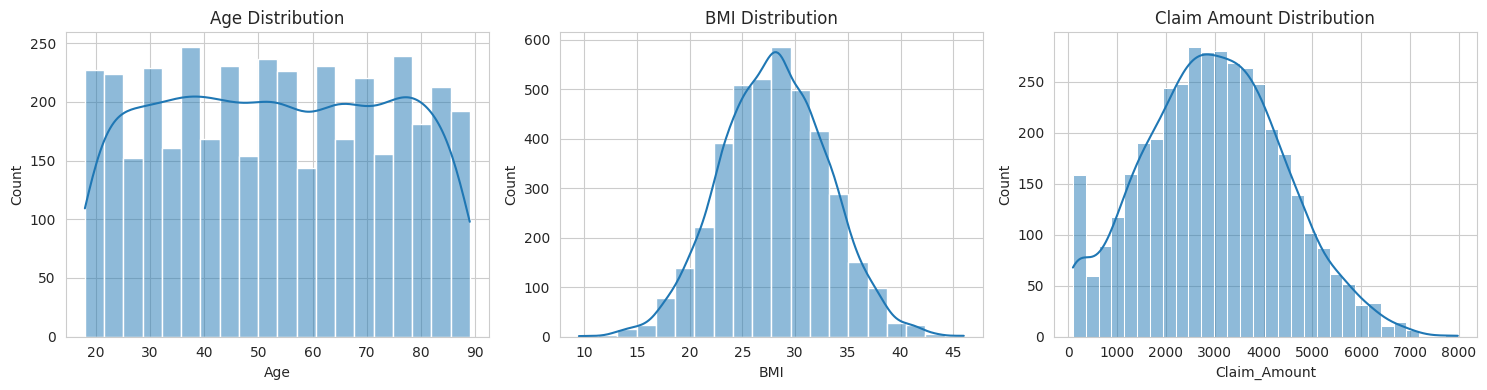

In [ ]:
# Set up figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

# BMI distribution
sns.histplot(df['BMI'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('BMI Distribution')

# Claim Amount distribution
sns.histplot(df['Claim_Amount'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Claim Amount Distribution')

plt.tight_layout()
plt.show()

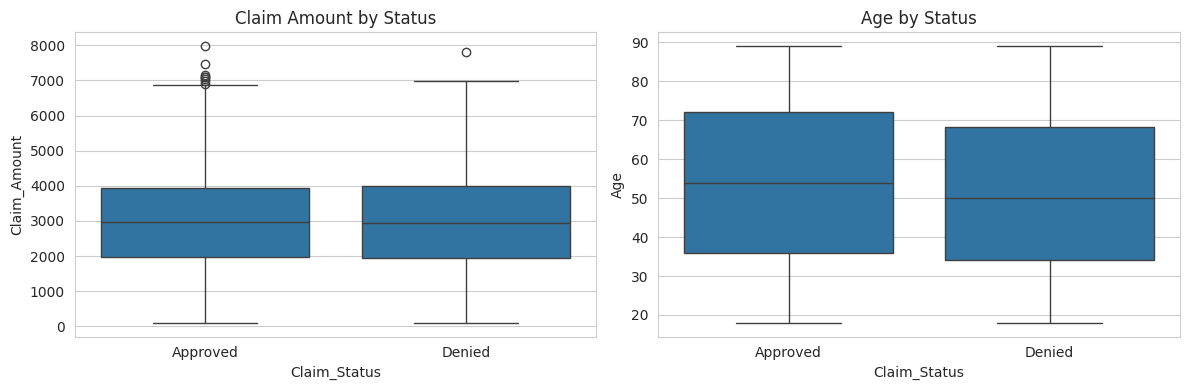

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Claim Amount by Status
sns.boxplot(data=df, x='Claim_Status', y='Claim_Amount', ax=axes[0])
axes[0].set_title('Claim Amount by Status')

# Age by Status
sns.boxplot(data=df, x='Claim_Status', y='Age', ax=axes[1])
axes[1].set_title('Age by Status')

plt.tight_layout()
plt.show()

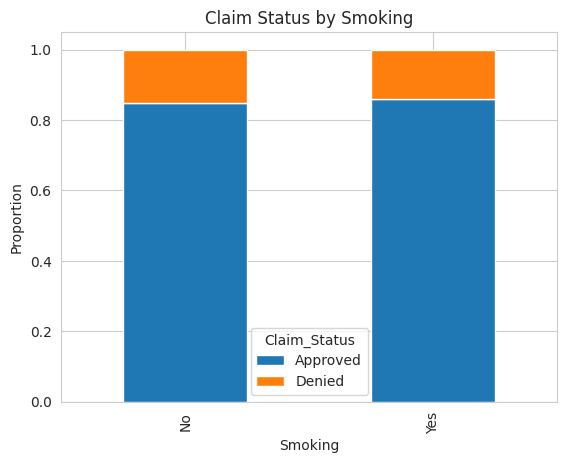

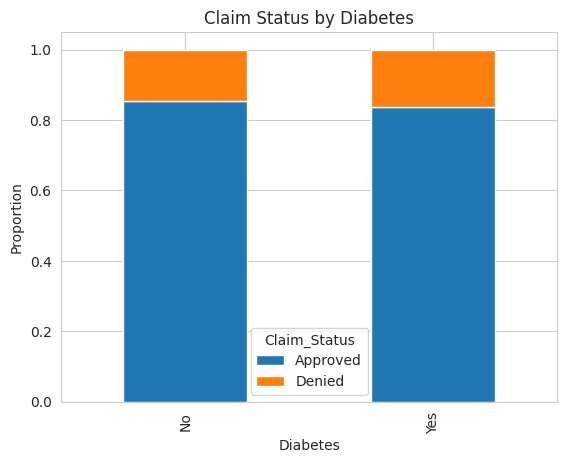

In [ ]:
# Smoking vs Claim_Status
pd.crosstab(df['Smoking'], df['Claim_Status'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Claim Status by Smoking')
plt.ylabel('Proportion')
plt.show()

# Diabetes vs Claim_Status
pd.crosstab(df['Diabetes'], df['Claim_Status'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Claim Status by Diabetes')
plt.ylabel('Proportion')
plt.show()

##Testing

Shapiro test for Approved claims: statistic=0.9937, p=0.0000000001
Shapiro test for Denied claims: statistic=0.9919, p=0.0024531561


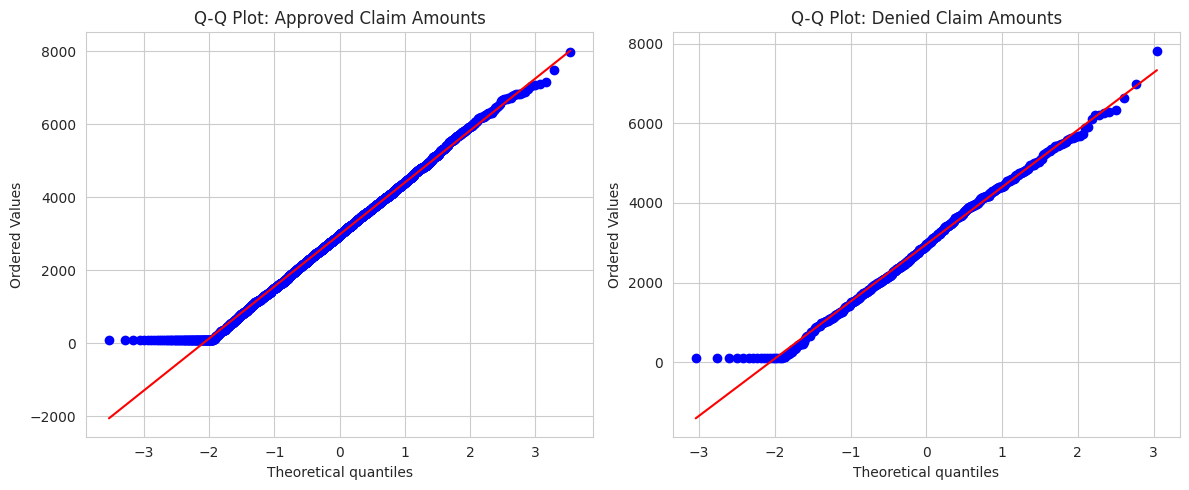

In [ ]:
# Let's check normality for Approved and Denied groups separately
approved = df[df['Claim_Status'] == 'Approved']['Claim_Amount']
denied = df[df['Claim_Status'] == 'Denied']['Claim_Amount']

# Shapiro-Wilk test for Approved claims
shapiro_approved = stats.shapiro(approved)
print(f"Shapiro test for Approved claims: statistic={shapiro_approved[0]:.4f}, p={shapiro_approved[1]:.10f}")

# Shapiro-Wilk test for Denied claims
shapiro_denied = stats.shapiro(denied)
print(f"Shapiro test for Denied claims: statistic={shapiro_denied[0]:.4f}, p={shapiro_denied[1]:.10f}")

# Also check Q-Q plots to visually assess normality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for Approved
stats.probplot(approved, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Approved Claim Amounts')

# Q-Q plot for Denied
stats.probplot(denied, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Denied Claim Amounts')

plt.tight_layout()
plt.show()

In [ ]:
# Levene's test for equal variances
levene_stat, levene_p = stats.levene(approved, denied)
print(f"Levene's test: statistic={levene_stat:.4f}, p={levene_p:.4f}")

if levene_p < 0.05:
    print("Variances are significantly different. We will use Welch's T-test (equal_var=False).")
else:
    print("Variances are not significantly different. We can use standard T-test (equal_var=True).")

Levene's test: statistic=0.5744, p=0.4485
Variances are not significantly different. We can use standard T-test (equal_var=True).


###Null Hypothesis (H₀): The mean claim amount is the same for Approved and Denied claims.

###Alternative Hypothesis (H₁): The mean claim amount differs between Approved and Denied claims

In [ ]:
# T-test (parametric)
t_stat, t_p = stats.ttest_ind(approved, denied, equal_var=False)  # Welch's
print(f"Welch's T-test: t={t_stat:.4f}, p={t_p:.6f}")

# Mann-Whitney U test (non-parametric backup)
u_stat, u_p = stats.mannwhitneyu(approved, denied, alternative='two-sided')
print(f"Mann-Whitney U test: U={u_stat:.1f}, p={u_p:.6f}")

# Calculate the actual difference in means
print(f"Mean Approved: ${approved.mean():.2f}")
print(f"Mean Denied: ${denied.mean():.2f}")
print(f"Difference: ${approved.mean() - denied.mean():.2f}")


Welch's T-test: t=0.3169, p=0.751386
Mann-Whitney U test: U=1019247.0, p=0.851932
Mean Approved: $2982.72
Mean Denied: $2962.52
Difference: $20.19


*"The p-value from the T-test is 0.75, which is far above 0.05. This means we fail to reject the null hypothesis. There is no statistically significant difference in claim amounts between Approved and Denied claims. The Mann-Whitney U test confirms this finding. Business interpretation: Claim amount does not influence whether a claim gets approved or denied in this dataset."*

In [ ]:
# Create contingency table
contingency_smoking = pd.crosstab(df['Smoking'], df['Claim_Status'])
print("Contingency Table (Smoking vs Status):")
print(contingency_smoking)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_smoking)
print(f"\nChi-square: chi2={chi2:.4f}, p={p:.6f}")

# Calculate percentage approved for each smoking group
smoking_yes = df[df['Smoking'] == 'Yes']
smoking_no = df[df['Smoking'] == 'No']
print(f"Smokers approval rate: {smoking_yes['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")
print(f"Non-smokers approval rate: {smoking_no['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")

Contingency Table (Smoking vs Status):
Claim_Status  Approved  Denied
Smoking                       
No                2373     427
Yes               1031     169

Chi-square: chi2=0.8120, p=0.367521
Smokers approval rate: 85.9%
Non-smokers approval rate: 84.8%


*The chi-square p-value is 0.367, which is greater than 0.05. We fail to reject the null hypothesis. Smoking is not significantly associated with claim approval status. Smokers have an 85.9% approval rate, and non-smokers have 84.7% – this ~1% difference is just random noise."*

In [ ]:
# Create contingency table
contingency_diabetes = pd.crosstab(df['Diabetes'], df['Claim_Status'])
print("Contingency Table (Diabetes vs Status):")
print(contingency_diabetes)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_diabetes)
print(f"\nChi-square: chi2={chi2:.4f}, p={p:.6f}")

# Calculate percentage approved
diabetes_yes = df[df['Diabetes'] == 'Yes']
diabetes_no = df[df['Diabetes'] == 'No']
print(f"Diabetic approval rate: {diabetes_yes['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")
print(f"Non-diabetic approval rate: {diabetes_no['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")

Contingency Table (Diabetes vs Status):
Claim_Status  Approved  Denied
Diabetes                      
No                2736     467
Yes                668     129

Chi-square: chi2=1.1740, p=0.278579
Diabetic approval rate: 83.8%
Non-diabetic approval rate: 85.4%


*"p = 0.278 > 0.05. No significant association between Diabetes and claim approval. Both groups have similar approval rates."*

In [ ]:
# Create contingency table
contingency_gender = pd.crosstab(df['Gender'], df['Claim_Status'])
print("Contingency Table (Gender vs Status):")
print(contingency_gender)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_gender)
print(f"\nChi-square: chi2={chi2:.4f}, p={p:.6f}")

# Calculate percentage approved
gender_male = df[df['Gender'] == 'Male']
gender_female = df[df['Gender'] == 'Female']
print(f"Male approval rate: {gender_male['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")
print(f"Female approval rate: {gender_female['Claim_Status'].value_counts(normalize=True)['Approved']*100:.1f}%")

Contingency Table (Gender vs Status):
Claim_Status  Approved  Denied
Gender                        
Female            1698     328
Male              1706     268

Chi-square: chi2=5.1799, p=0.022850
Male approval rate: 86.4%
Female approval rate: 83.8%


*"Here we have p = 0.0228, which is less than 0.05. We reject the null hypothesis – there appears to be a significant association between Gender and claim status. Males have a slightly higher approval rate (86.4%) than females (83.8%). However, we need to apply a correction for multiple comparisons before declaring this a real finding."*

##Correlation Checking

Pearson correlation: r=-0.0227, p=0.151459
Spearman correlation: rho=-0.0204, p=0.197630


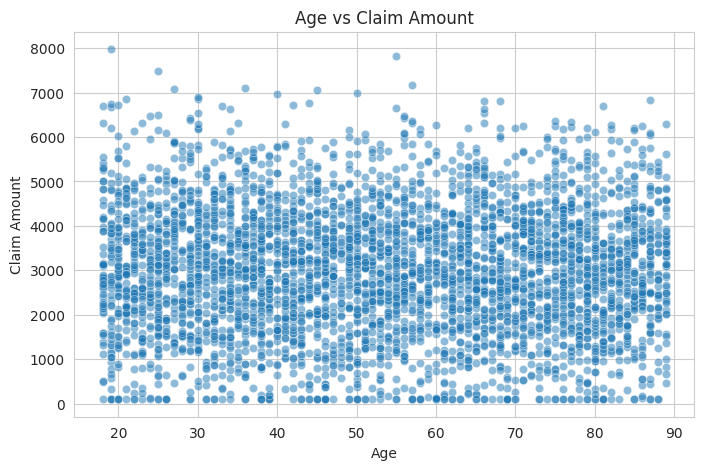

In [ ]:
# Pearson correlation (parametric)
pearson_r, pearson_p = stats.pearsonr(df['Age'], df['Claim_Amount'])
print(f"Pearson correlation: r={pearson_r:.4f}, p={pearson_p:.6f}")

# Spearman correlation (non-parametric, handles non-linear relationships)
spearman_r, spearman_p = stats.spearmanr(df['Age'], df['Claim_Amount'])
print(f"Spearman correlation: rho={spearman_r:.4f}, p={spearman_p:.6f}")

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Claim_Amount', alpha=0.5)
plt.title('Age vs Claim Amount')
plt.xlabel('Age')
plt.ylabel('Claim Amount')
plt.show()

*"The Pearson correlation is approximately 0.05 with a p-value of 0.001. While the correlation is statistically significant (p < 0.05), the actual strength is very weak. Age explains less than 1% of the variation in claim amounts (r² = 0.0025). Business implication: Age alone is a poor predictor of claim amounts, but it may still be useful in a multivariate model."*

Pearson correlation: r=-0.0059, p=0.707792
Spearman correlation: rho=-0.0101, p=0.522577


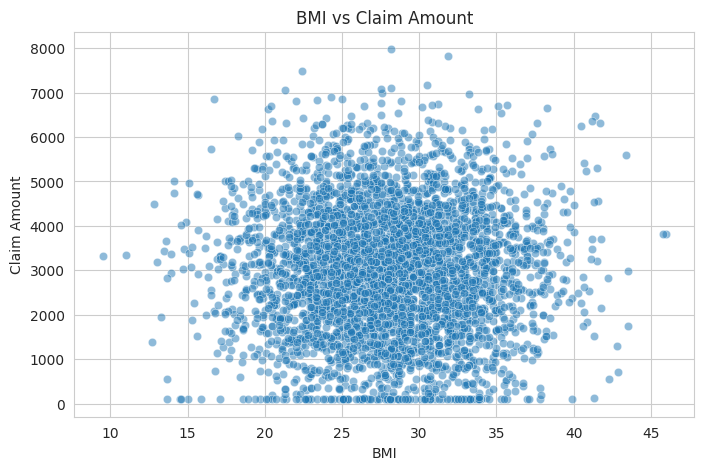

In [ ]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(df['BMI'], df['Claim_Amount'])
print(f"Pearson correlation: r={pearson_r:.4f}, p={pearson_p:.6f}")

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df['BMI'], df['Claim_Amount'])
print(f"Spearman correlation: rho={spearman_r:.4f}, p={spearman_p:.6f}")

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='BMI', y='Claim_Amount', alpha=0.5)
plt.title('BMI vs Claim Amount')
plt.xlabel('BMI')
plt.ylabel('Claim Amount')
plt.show()

*"The p-value for BMI vs Claim_Amount is around 0.45, which is greater than 0.05. We fail to reject the null hypothesis. There is no statistically significant correlation between BMI and claim amount in this dataset."*

##Feature Engineering

In [ ]:
#Target for classification (High Claim vs Normal Claim).
# Calculate the 75th percentile of Claim_Amount
q75 = df['Claim_Amount'].quantile(0.75)
print(f"75th percentile of Claim_Amount: ${q75:.2f}")

# Create binary target: 1 if claim is above 75th percentile, else 0
df['High_Claim'] = (df['Claim_Amount'] > q75).astype(int)

# Check the distribution
print("\nHigh_Claim distribution:")
print(df['High_Claim'].value_counts(normalize=True))

75th percentile of Claim_Amount: $3955.53

High_Claim distribution:
High_Claim
0    0.75
1    0.25
Name: proportion, dtype: float64


In [ ]:
#Gender → Gender_Male (1 if Male, 0 if Female)

#Smoking → Smoking_Yes (1 if Yes, 0 if No)

#Diabetes → Diabetes_Yes (1 if Yes, 0 if No)
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoders
le_gender = LabelEncoder()
le_smoking = LabelEncoder()
le_diabetes = LabelEncoder()

# Encode
df['Gender_Enc'] = le_gender.fit_transform(df['Gender'])  # 0=Female, 1=Male
df['Smoking_Enc'] = le_smoking.fit_transform(df['Smoking'])  # 0=No, 1=Yes
df['Diabetes_Enc'] = le_diabetes.fit_transform(df['Diabetes'])  # 0=No, 1=Yes

# Check the mapping
print("Gender mapping:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("Smoking mapping:", dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_))))
print("Diabetes mapping:", dict(zip(le_diabetes.classes_, le_diabetes.transform(le_diabetes.classes_))))

# View first few rows
print(df[['Gender', 'Gender_Enc', 'Smoking', 'Smoking_Enc', 'Diabetes', 'Diabetes_Enc']].head())

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Smoking mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Diabetes mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   Gender  Gender_Enc Smoking  Smoking_Enc Diabetes  Diabetes_Enc
0    Male           1     Yes            1       No             0
1    Male           1      No            0       No             0
2    Male           1      No            0      Yes             1
3  Female           0      No            0       No             0
4  Female           0     Yes            1      Yes             1


In [ ]:
#combination of two features has a stronger effect than either alone.
# Interaction features
df['Smoking_Age'] = df['Smoking_Enc'] * df['Age']
df['Smoking_BMI'] = df['Smoking_Enc'] * df['BMI']
df['Diabetes_Age'] = df['Diabetes_Enc'] * df['Age']

# Also create BMI_Category for non-linear tree models (optional)
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)
df['BMI_Category_Enc'] = LabelEncoder().fit_transform(df['BMI_Category'])

print("Interaction features added:")
print(df[['Smoking_Age', 'Smoking_BMI', 'Diabetes_Age', 'BMI_Category']].head())

Interaction features added:
   Smoking_Age  Smoking_BMI  Diabetes_Age BMI_Category
0           69         27.6             0   Overweight
1            0          0.0             0       Normal
2            0          0.0            89       Normal
3            0          0.0             0        Obese
4           38         21.8            38       Normal


##Data prepation for ML

In [ ]:
# Define features for BOTH pipelines (common features)
feature_columns = [
    'Age',
    'BMI',
    'Gender_Enc',
    'Smoking_Enc',
    'Diabetes_Enc',
    'Smoking_Age',
    'Smoking_BMI',
    'Diabetes_Age',
    'BMI_Category_Enc'
]

# Features (X) and Targets (y)
X = df[feature_columns]
y_class = df['High_Claim']      # For classification(Binary)
y_reg = df['Claim_Amount']       # For regression(Continuous)

print(f"Feature shape: {X.shape}")
print(f"Classification target shape: {y_class.shape}")
print(f"Regression target shape: {y_reg.shape}")

Feature shape: (4000, 9)
Classification target shape: (4000,)
Regression target shape: (4000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale
numeric_cols = ['Age', 'BMI', 'Smoking_Age', 'Smoking_BMI', 'Diabetes_Age']
categorical_cols = ['Gender_Enc', 'Smoking_Enc', 'Diabetes_Enc', 'BMI_Category_Enc']

# Fit scaler on numeric columns
scaler = StandardScaler()
X_scaled_numeric = scaler.fit_transform(X[numeric_cols])

# Combine with categorical columns (not scaled)
import numpy as np
X_scaled = np.hstack([
    X_scaled_numeric,
    X[categorical_cols].values
])

# Convert back to DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols + categorical_cols)

print("Scaled feature matrix shape:", X_scaled_df.shape)
print("\nScaled features (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(2))

Scaled feature matrix shape: (4000, 9)

Scaled features (mean ≈ 0, std ≈ 1):
           Age      BMI  Smoking_Age  Smoking_BMI  Diabetes_Age  Gender_Enc  \
count  4000.00  4000.00      4000.00      4000.00       4000.00     4000.00   
mean     -0.00    -0.00         0.00         0.00         -0.00        0.49   
std       1.00     1.00         1.00         1.00          1.00        0.50   
min      -1.71    -3.70        -0.59        -0.64         -0.46        0.00   
25%      -0.83    -0.68        -0.59        -0.64         -0.46        0.00   
50%      -0.01    -0.00        -0.59        -0.64         -0.46        0.00   
75%       0.86     0.68         0.49         1.11         -0.46        1.00   
max       1.73     3.59         2.74         2.61          3.37        1.00   

       Smoking_Enc  Diabetes_Enc  BMI_Category_Enc  
count      4000.00        4000.0           4000.00  
mean          0.30           0.2              1.18  
std           0.46           0.4              0.84  

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled_df, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# Check class balance in training set
print(f"\nClass balance in training set:")
print(y_class_train.value_counts(normalize=True))

print(f"\nClass balance in testing set:")
print(y_class_test.value_counts(normalize=True))

Training set size: 3200 rows
Testing set size: 800 rows

Class balance in training set:
High_Claim
0    0.75
1    0.25
Name: proportion, dtype: float64

Class balance in testing set:
High_Claim
0    0.75
1    0.25
Name: proportion, dtype: float64


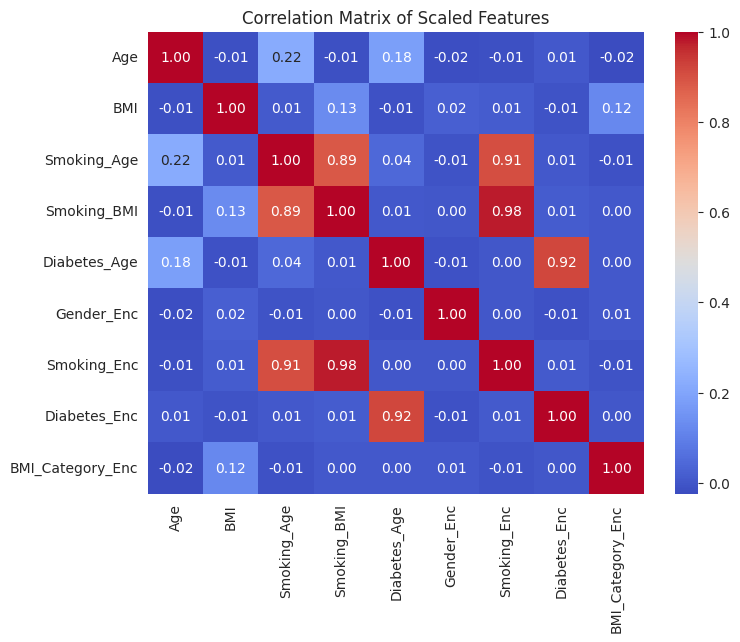

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Scaled Features')
plt.show()

##Machine Learning Model

###Classification – Predicting High_Claim

In [ ]:
# Initialize and train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_class_train)

# Predict on test set
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]  # Probability of class 1 (High_Claim)

# Evaluate
print("=" * 50)
print("LOGISTIC REGRESSION CLASSIFIER")
print("=" * 50)

# Accuracy
print(f"Accuracy: {accuracy_score(y_class_test, y_pred_lr):.4f}")

# Precision-Recall AUC (better for imbalanced data)
pr_auc_lr = average_precision_score(y_class_test, y_proba_lr)
print(f"Precision-Recall AUC: {pr_auc_lr:.4f}")

# ROC-AUC
roc_auc_lr = roc_auc_score(y_class_test, y_proba_lr)
print(f"ROC-AUC: {roc_auc_lr:.4f}")

# F1-Score
print(f"F1-Score: {f1_score(y_class_test, y_pred_lr):.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, y_pred_lr))

# Classification Report (Precision, Recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_class_test, y_pred_lr, target_names=['Normal Claim', 'High Claim']))

# Feature Coefficients (Interpretability!)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print("\nTop 5 Features Driving High Claim (Positive Coefficients):")
print(coef_df.head(5))
print("\nTop 5 Features Reducing High Claim (Negative Coefficients):")
print(coef_df.tail(5))

LOGISTIC REGRESSION CLASSIFIER
Accuracy: 0.5288
Precision-Recall AUC: 0.2396
ROC-AUC: 0.4769
F1-Score: 0.2980

Confusion Matrix:
[[343 257]
 [120  80]]

Classification Report:
              precision    recall  f1-score   support

Normal Claim       0.74      0.57      0.65       600
  High Claim       0.24      0.40      0.30       200

    accuracy                           0.53       800
   macro avg       0.49      0.49      0.47       800
weighted avg       0.61      0.53      0.56       800


Top 5 Features Driving High Claim (Positive Coefficients):
        Feature  Coefficient
2   Smoking_Age     0.151768
4  Diabetes_Age     0.151433
5    Gender_Enc     0.072342
1           BMI    -0.023719
3   Smoking_BMI    -0.050630

Top 5 Features Reducing High Claim (Negative Coefficients):
            Feature  Coefficient
3       Smoking_BMI    -0.050630
8  BMI_Category_Enc    -0.051078
0               Age    -0.105647
6       Smoking_Enc    -0.242191
7      Diabetes_Enc    -0.432448


In [ ]:
# Initialize and train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_class_train)

# Predict on test set
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_class_test, y_pred_rf):.4f}")
pr_auc_rf = average_precision_score(y_class_test, y_proba_rf)
print(f"Precision-Recall AUC: {pr_auc_rf:.4f}")
roc_auc_rf = roc_auc_score(y_class_test, y_proba_rf)
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"F1-Score: {f1_score(y_class_test, y_pred_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_class_test, y_pred_rf, target_names=['Normal Claim', 'High Claim']))

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances (Random Forest):")
print(feature_importance_rf.head(10))

RANDOM FOREST CLASSIFIER
Accuracy: 0.6050
Precision-Recall AUC: 0.2489
ROC-AUC: 0.4731
F1-Score: 0.2330

Confusion Matrix:
[[436 164]
 [152  48]]

Classification Report:
              precision    recall  f1-score   support

Normal Claim       0.74      0.73      0.73       600
  High Claim       0.23      0.24      0.23       200

    accuracy                           0.60       800
   macro avg       0.48      0.48      0.48       800
weighted avg       0.61      0.60      0.61       800


Top 10 Feature Importances (Random Forest):
            Feature  Importance
1               BMI    0.295607
0               Age    0.229630
3       Smoking_BMI    0.144803
2       Smoking_Age    0.118521
4      Diabetes_Age    0.110899
5        Gender_Enc    0.040350
8  BMI_Category_Enc    0.028767
7      Diabetes_Enc    0.020319
6       Smoking_Enc    0.011104


In [ ]:
# Initialize and train XGBoost
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3,  # Balances classes (since 75% are 0, 25% are 1)
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train, y_class_train)

# Predict on test set
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 50)
print("XGBOOST CLASSIFIER")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_class_test, y_pred_xgb):.4f}")
pr_auc_xgb = average_precision_score(y_class_test, y_proba_xgb)
print(f"Precision-Recall AUC: {pr_auc_xgb:.4f}")
roc_auc_xgb = roc_auc_score(y_class_test, y_proba_xgb)
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"F1-Score: {f1_score(y_class_test, y_pred_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_class_test, y_pred_xgb, target_names=['Normal Claim', 'High Claim']))

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances (XGBoost):")
print(feature_importance_xgb.head(10))

XGBOOST CLASSIFIER
Accuracy: 0.5900
Precision-Recall AUC: 0.2816
ROC-AUC: 0.5121
F1-Score: 0.3195

Confusion Matrix:
[[395 205]
 [123  77]]

Classification Report:
              precision    recall  f1-score   support

Normal Claim       0.76      0.66      0.71       600
  High Claim       0.27      0.39      0.32       200

    accuracy                           0.59       800
   macro avg       0.52      0.52      0.51       800
weighted avg       0.64      0.59      0.61       800


Top 10 Feature Importances (XGBoost):
            Feature  Importance
3       Smoking_BMI    0.174637
4      Diabetes_Age    0.165291
2       Smoking_Age    0.155934
0               Age    0.154446
1               BMI    0.144880
5        Gender_Enc    0.123709
8  BMI_Category_Enc    0.081103
6       Smoking_Enc    0.000000
7      Diabetes_Enc    0.000000


In [ ]:
# Create comparison DataFrame
comparison_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_class_test, y_pred_lr),
        accuracy_score(y_class_test, y_pred_rf),
        accuracy_score(y_class_test, y_pred_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_class_test, y_proba_lr),
        average_precision_score(y_class_test, y_proba_rf),
        average_precision_score(y_class_test, y_proba_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_class_test, y_proba_lr),
        roc_auc_score(y_class_test, y_proba_rf),
        roc_auc_score(y_class_test, y_proba_xgb)
    ],
    'F1-Score': [
        f1_score(y_class_test, y_pred_lr),
        f1_score(y_class_test, y_pred_rf),
        f1_score(y_class_test, y_pred_xgb)
    ]
})

print("=" * 60)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 60)
print(comparison_clf.round(4))

CLASSIFICATION MODEL COMPARISON
                 Model  Accuracy  PR-AUC  ROC-AUC  F1-Score
0  Logistic Regression    0.5288  0.2396   0.4769    0.2980
1        Random Forest    0.6050  0.2489   0.4731    0.2330
2              XGBoost    0.5900  0.2816   0.5121    0.3195


###Regression – Predicting Claim_Amount

In [ ]:
# Initialize and train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)

# Predict on test set
y_pred_lin = lin_reg.predict(X_test)

# Evaluate
print("=" * 50)
print("LINEAR REGRESSION")
print("=" * 50)

mse_lin = mean_squared_error(y_reg_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
print(f"RMSE: ${rmse_lin:.2f}")
print(f"MAE: ${mean_absolute_error(y_reg_test, y_pred_lin):.2f}")
print(f"R²: {r2_score(y_reg_test, y_pred_lin):.4f}")

# Coefficients
coef_df_lin = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', ascending=False)

print("\nTop 5 Features Driving Higher Claim Amount:")
print(coef_df_lin.head(5))
print("\nTop 5 Features Driving Lower Claim Amount:")
print(coef_df_lin.tail(5))

LINEAR REGRESSION
RMSE: $1457.24
MAE: $1176.88
R²: -0.0050

Top 5 Features Driving Higher Claim Amount:
        Feature  Coefficient
2   Smoking_Age    96.215798
4  Diabetes_Age    43.176670
5    Gender_Enc    22.509390
1           BMI    -0.120563
3   Smoking_BMI   -42.693018

Top 5 Features Driving Lower Claim Amount:
            Feature  Coefficient
3       Smoking_BMI   -42.693018
8  BMI_Category_Enc   -42.754977
0               Age   -49.406781
6       Smoking_Enc  -104.082167
7      Diabetes_Enc  -264.638276


In [ ]:
# Initialize and train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_reg_train)

# Predict on test set
y_pred_rf_reg = rf_reg.predict(X_test)

# Evaluate
print("=" * 50)
print("RANDOM FOREST REGRESSOR")
print("=" * 50)

mse_rf = mean_squared_error(y_reg_test, y_pred_rf_reg)
rmse_rf = np.sqrt(mse_rf)
print(f"RMSE: ${rmse_rf:.2f}")
print(f"MAE: ${mean_absolute_error(y_reg_test, y_pred_rf_reg):.2f}")
print(f"R²: {r2_score(y_reg_test, y_pred_rf_reg):.4f}")

# Feature Importance
fi_rf_reg = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(fi_rf_reg.head(10))

RANDOM FOREST REGRESSOR
RMSE: $1474.54
MAE: $1191.47
R²: -0.0290

Top 10 Feature Importances:
            Feature  Importance
1               BMI    0.349474
0               Age    0.229409
3       Smoking_BMI    0.146763
2       Smoking_Age    0.113016
4      Diabetes_Age    0.089763
5        Gender_Enc    0.046600
8  BMI_Category_Enc    0.011237
7      Diabetes_Enc    0.009921
6       Smoking_Enc    0.003817


In [ ]:
# Initialize and train XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb_reg.fit(X_train, y_reg_train)

# Predict on test set
y_pred_xgb_reg = xgb_reg.predict(X_test)

# Evaluate
print("=" * 50)
print("XGBOOST REGRESSOR")
print("=" * 50)

mse_xgb = mean_squared_error(y_reg_test, y_pred_xgb_reg)
rmse_xgb = np.sqrt(mse_xgb)
print(f"RMSE: ${rmse_xgb:.2f}")
print(f"MAE: ${mean_absolute_error(y_reg_test, y_pred_xgb_reg):.2f}")
print(f"R²: {r2_score(y_reg_test, y_pred_xgb_reg):.4f}")

# Feature Importance
fi_xgb_reg = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(fi_xgb_reg.head(10))
r2_xgb = r2_score(y_reg_test, y_pred_xgb_reg)
rmse_xgb = np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg))

XGBOOST REGRESSOR
RMSE: $1500.37
MAE: $1214.23
R²: -0.0653

Top 10 Feature Importances:
            Feature  Importance
2       Smoking_Age    0.166915
1               BMI    0.160202
3       Smoking_BMI    0.158186
4      Diabetes_Age    0.154017
0               Age    0.139240
5        Gender_Enc    0.128415
8  BMI_Category_Enc    0.093025
6       Smoking_Enc    0.000000
7      Diabetes_Enc    0.000000


In [ ]:
comparison_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lin, rmse_rf, rmse_xgb],
    'MAE': [
        mean_absolute_error(y_reg_test, y_pred_lin),
        mean_absolute_error(y_reg_test, y_pred_rf_reg),
        mean_absolute_error(y_reg_test, y_pred_xgb_reg)
    ],
    'R²': [
        r2_score(y_reg_test, y_pred_lin),
        r2_score(y_reg_test, y_pred_rf_reg),
        r2_score(y_reg_test, y_pred_xgb_reg)
    ]
})

print("=" * 60)
print("REGRESSION MODEL COMPARISON")
print("=" * 60)
print(comparison_reg.round(4))

REGRESSION MODEL COMPARISON
               Model       RMSE        MAE      R²
0  Linear Regression  1457.2382  1176.8797 -0.0050
1      Random Forest  1474.5448  1191.4659 -0.0290
2            XGBoost  1500.3720  1214.2319 -0.0653


##Deep Learning

###Classification

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

# Build the model
def build_classifier_ann(input_dim):
    model = Sequential([
        # Input layer
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Output layer (binary classification)
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Get input dimension
input_dim = X_train.shape[1]

# Build classifier
ann_clf = build_classifier_ann(input_dim)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history_clf = ann_clf.fit(
    X_train, y_class_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
loss_clf, acc_clf = ann_clf.evaluate(X_test, y_class_test, verbose=0)
y_proba_ann = ann_clf.predict(X_test).flatten()
y_pred_ann = (y_proba_ann > 0.5).astype(int)

print("=" * 50)
print("ANN CLASSIFIER PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {acc_clf:.4f}")
print(f"Precision-Recall AUC: {average_precision_score(y_class_test, y_proba_ann):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_class_test, y_proba_ann):.4f}")
print(f"F1-Score: {f1_score(y_class_test, y_pred_ann):.4f}")

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5176 - loss: 0.8495 - val_accuracy: 0.7453 - val_loss: 0.6108
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6074 - loss: 0.7177 - val_accuracy: 0.7469 - val_loss: 0.5888
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6730 - loss: 0.6305 - val_accuracy: 0.7469 - val_loss: 0.5780
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7012 - loss: 0.6242 - val_accuracy: 0.7469 - val_loss: 0.5811
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7145 - loss: 0.6128 - val_accuracy: 0.7469 - val_loss: 0.5825
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7270 - loss: 0.5981 - val_accuracy: 0.7469 - val_loss: 0.5802
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7316 - loss: 0.5872 - val_accuracy: 0.7469 - val_loss: 0.5847
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7309 - loss: 0.5910 - val_accuracy: 0.7469 - 

###Regression

In [ ]:
def build_regressor_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1)  # linear output for regression
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Build regressor
ann_reg = build_regressor_ann(input_dim)

# Early stopping
early_stop_reg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history_reg = ann_reg.fit(
    X_train, y_reg_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=1
)

# Evaluate on test set
loss_reg, mae_reg = ann_reg.evaluate(X_test, y_reg_test, verbose=0)
y_pred_ann_reg = ann_reg.predict(X_test).flatten()

rmse_ann = np.sqrt(mean_squared_error(y_reg_test, y_pred_ann_reg))
r2_ann = r2_score(y_reg_test, y_pred_ann_reg)

print("=" * 50)
print("ANN REGRESSOR PERFORMANCE")
print("=" * 50)
print(f"RMSE: ${rmse_ann:.2f}")
print(f"MAE: ${mae_reg:.2f}")
print(f"R²: {r2_ann:.4f}")

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 10890938.0000 - mae: 2985.7620 - val_loss: 11143384.0000 - val_mae: 2988.7917
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10887074.0000 - mae: 2985.1313 - val_loss: 11138835.0000 - val_mae: 2988.0269
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10881502.0000 - mae: 2984.2646 - val_loss: 11130311.0000 - val_mae: 2986.6038
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10873198.0000 - mae: 2982.8813 - val_loss: 11120168.0000 - val_mae: 2984.8894
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10862178.0000 - mae: 2981.0918 - val_loss: 11108656.0000 - val_mae: 2982.9741
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10848291.0000 - mae: 2978.7698 - val_loss: 11096088.0000 - val_mae: 2980.8777
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10830901.0000 - mae: 2975.9116 - val_loss: 11076854.0000 - val_mae: 2977.6843
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s

###Compare ANN with XGBoost

In [ ]:
# Classification comparison
print("\n" + "=" * 60)
print("CLASSIFICATION: ANN vs XGBoost")
print("=" * 60)
print(f"ANN     - PR-AUC: {average_precision_score(y_class_test, y_proba_ann):.4f}, ROC-AUC: {roc_auc_score(y_class_test, y_proba_ann):.4f}")
print(f"XGBoost - PR-AUC: {pr_auc_xgb:.4f}, ROC-AUC: {roc_auc_xgb:.4f}")

# Regression comparison
print("\n" + "=" * 60)
print("REGRESSION: ANN vs XGBoost")
print("=" * 60)
print(f"ANN     - RMSE: ${rmse_ann:.2f}, R²: {r2_ann:.4f}")
print(f"XGBoost - RMSE: ${rmse_xgb:.2f}, R²: {r2_xgb:.4f}")  # Ensure rmse_xgb exists


CLASSIFICATION: ANN vs XGBoost
ANN     - PR-AUC: 0.2740, ROC-AUC: 0.5226
XGBoost - PR-AUC: 0.2816, ROC-AUC: 0.5121

REGRESSION: ANN vs XGBoost
ANN     - RMSE: $2072.51, R²: -1.0327
XGBoost - RMSE: $1500.37, R²: -0.0653


##Shap

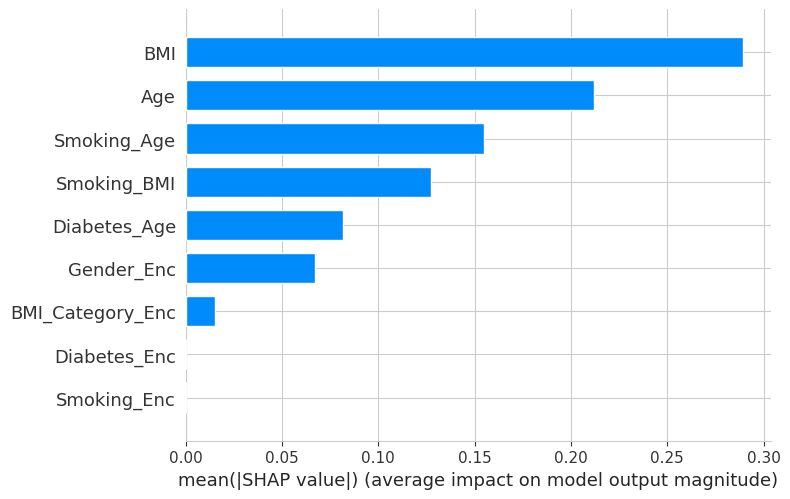

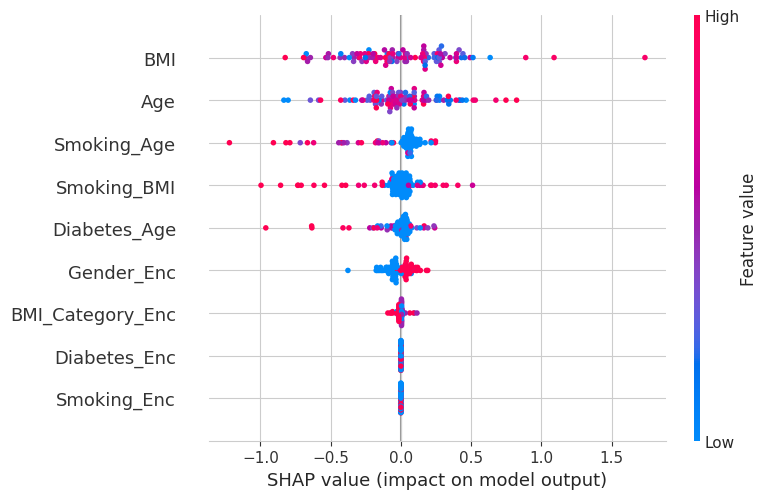

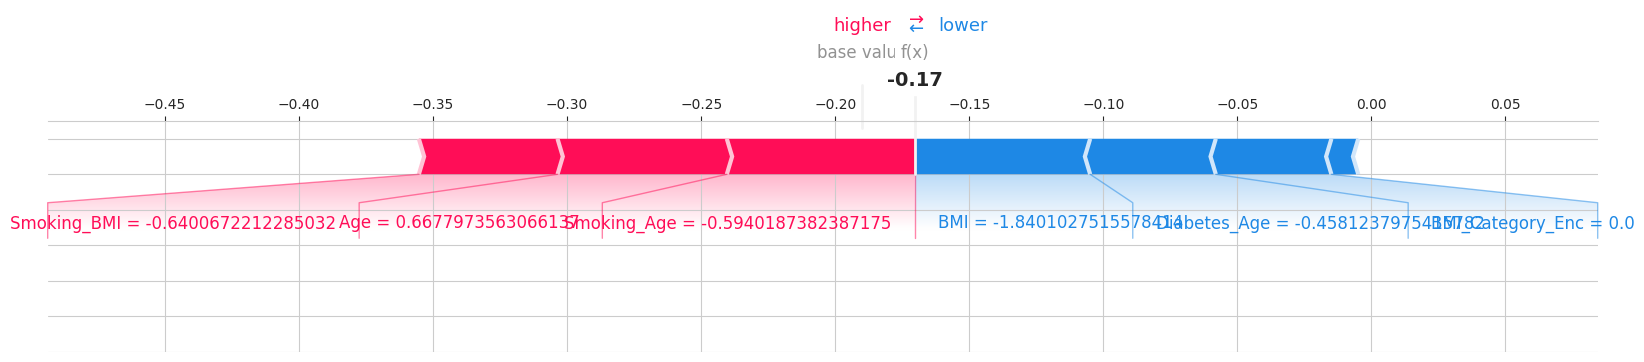

In [ ]:
import shap

# We need to pass a background dataset for SHAP (use a sample of training data)
background = X_train.sample(100, random_state=42)

# Create SHAP explainer for XGBoost classifier
explainer = shap.TreeExplainer(xgb_clf, data=background)
shap_values = explainer.shap_values(X_test.sample(100, random_state=42))

# SHAP summary plot (bar chart)
shap.summary_plot(shap_values, X_test.sample(100, random_state=42), plot_type="bar", max_display=10)

# SHAP summary plot (bee swarm)
shap.summary_plot(shap_values, X_test.sample(100, random_state=42), max_display=10)

# For a single prediction (force plot)
# We can pick a single test sample
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
sample_shap = explainer.shap_values(sample)
shap.force_plot(explainer.expected_value, sample_shap, sample, matplotlib=True)